# Terrain Generalization Diagnostics

Run `scripts/diagnose_joint_baseline_strategies.py` for every configured approach-terrain pair, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the same core joint performance metrics used in `03_baseline_comparison.ipynb`:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std
- scout, confirmation, confidence, and coverage AUC
- time to 100%, 80%, and 50% confirmation recall
- scout-to-confirm latency

Edit the run settings in the first code cell. If `FILELIST` is empty, the notebook runs only missing approach-terrain diagnostics, with up to `MAX_PARALLEL_RUNS` jobs running concurrently. Each output name replaces `malibu` in `MODNAME` with the terrain dictionary key. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.


In [10]:
# Terrain-generalization configuration. MODNAME must contain the source terrain key 'malibu'.
MODNAME = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099
# Sweep over the number of active true survivors in each episode.
# The checkpoint's survivor-slot count is preserved by default. Set SURVIVOR_SLOT_COUNT
# only when running without a checkpoint or when you intentionally want to override it.
STRATEGIES = ['happo', 'ant_colony', 'lawnmower']
COMMS_DROPOUT = 0.0

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 5
NSURVIVORS_MAX = 10

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
# Use 1 for sequential execution; increase carefully because each diagnostic is CPU intensive.
MAX_PARALLEL_RUNS = 2
EXTRA_DIAGNOSTIC_ARGS = []

TERRAIN={
    "malibu": "data/terrain_cache/malibu_creek_1sqkm_256.npz",
    "aubern": "data/terrain_cache/aubern_sra_1sqkm_256.npz",
    "topanga": "data/terrain_cache/topanga_state_park_1sqkm_256.npz",
    "san_marcos": "data/terrain_cache/san_marcos_foothills_1sqkm_256.npz"
}

# Optional: provide existing diagnostic JSON outputs here to skip all diagnostic execution.
FILELIST = []
# FILELIST = [
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
# ]

# Optional display labels for FILELIST entries. Leave empty to derive approach and terrain labels.
LABELS = []


In [11]:
import json
import shlex
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
if (CWD / 'scripts' / 'diagnose_joint_baseline_strategies.py').is_file():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'scripts' / 'diagnose_joint_baseline_strategies.py').is_file():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'terrain_generalization'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

STRATEGY_LABELS = {
    'happo': 'OmniSearch RL',
    'ant_colony': 'ACO',
    'lawnmower': 'Lawnmower',
    'random_walk': 'Random Walk',
    'random_action': 'Random Action',
    'highest_confidence': 'Highest Confidence',
}
TERRAIN_LABELS = {
    'malibu': 'Malibu Creek State Park',
    'aubern': 'Auburn SRA',
    'topanga': 'Topanga State Park',
    'san_marcos': 'San Marcos Foothills',
}


def _resolve_checkpoint(ckpt):
    path = Path(ckpt).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    if not path.is_dir():
        raise FileNotFoundError(f'Checkpoint directory not found: {path}')
    return path.resolve()


def _resolve_terrain_cache(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    if not path.is_file():
        raise FileNotFoundError(f'Terrain cache not found: {path}')
    return path.resolve()


def _modname_for_terrain(terrain_name):
    if 'malibu' not in MODNAME:
        raise ValueError("MODNAME must contain 'malibu' so it can be replaced by the terrain name")
    return MODNAME.replace('malibu', str(terrain_name))


def _diagnostic_output_paths(strategy, terrain_name):
    strategy_tag = str(strategy).replace('-', '_')
    stem = f'{strategy_tag}_{_modname_for_terrain(terrain_name)}_seeds_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'


def _resolve_json_file(path):
    path = Path(path).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([PROJECT_ROOT / path, PROJECT_ROOT / 'notebooks' / path])
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()


In [12]:
def _run_diagnostic_job(strategy, terrain_name, cmd, log_path):
    with log_path.open('w') as log:
        subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            check=True,
            stdout=log,
            stderr=subprocess.STDOUT,
        )
    return strategy, terrain_name


if len(STRATEGIES) != len(set(STRATEGIES)):
    raise ValueError('STRATEGIES contains duplicates')
if not TERRAIN:
    raise ValueError('TERRAIN must contain at least one terrain cache')
if int(MAX_PARALLEL_RUNS) < 1:
    raise ValueError('MAX_PARALLEL_RUNS must be at least 1')

if FILELIST:
    JSON_FILES = [_resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    checkpoint = _resolve_checkpoint(CKPT)
    terrain_caches = {
        name: _resolve_terrain_cache(path)
        for name, path in TERRAIN.items()
    }
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]
    JSON_FILES = []
    jobs = []

    for strategy in STRATEGIES:
        for terrain_name, terrain_cache in terrain_caches.items():
            json_output, plots_output = _diagnostic_output_paths(strategy, terrain_name)
            JSON_FILES.append(json_output)
            should_run = RUN_DIAGNOSTICS and (
                FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()
            )
            run_label = f'{strategy}/{terrain_name}'
            if not should_run:
                print(f'Using existing {run_label}:', json_output)
                continue

            cmd = [
                sys.executable,
                str(PROJECT_ROOT / 'scripts/diagnose_joint_baseline_strategies.py'),
                '--strategy', strategy,
                '--happo-checkpoint', str(checkpoint),
                '--terrain-cache-path', str(terrain_cache),
                '--steps', str(NSTEPS_PER_EPISODE),
                '--seeds', *seeds,
                '--comms-dropout', str(COMMS_DROPOUT),
                '--n-survivors', str(NSURVIVORS_OBS),
                '--active-survivors-min', str(NSURVIVORS_MIN),
                '--active-survivors-max', str(NSURVIVORS_MAX),
                '--json-output', str(json_output),
                '--plots-output', str(plots_output),
            ]
            cmd.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
            log_path = json_output.with_suffix('.log')
            jobs.append((strategy, terrain_name, cmd, log_path))
            print(f'Queued {run_label}:', shlex.join(cmd))
            print('Log:', log_path)

    if jobs:
        workers = min(int(MAX_PARALLEL_RUNS), len(jobs))
        print(f'Running {len(jobs)} missing diagnostic(s) with {workers} worker(s).')
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {
                executor.submit(
                    _run_diagnostic_job, strategy, terrain_name, cmd, log_path
                ): (strategy, terrain_name, log_path)
                for strategy, terrain_name, cmd, log_path in jobs
            }
            for future in as_completed(futures):
                strategy, terrain_name, log_path = futures[future]
                future.result()
                print(f'Finished {strategy}/{terrain_name}; log={log_path}')

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(path) for path in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)


Using existing happo/malibu: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/aubern: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/topanga: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/san_marcos: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Loaded file list: 4 JSON file(s)
 - outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropo

In [13]:
def _summary_value(summary, *keys, default=float('nan')):
    for key in keys:
        if key in summary:
            return summary[key]
    return default


def _payload_scenario(payload):
    scenario = payload.get('scenario')
    if isinstance(scenario, dict) and scenario:
        return scenario
    scenario_kwargs = payload.get('scenario_kwargs')
    if isinstance(scenario_kwargs, dict) and scenario_kwargs:
        return scenario_kwargs
    metadata = payload.get('metadata', {})
    scenario_kwargs = metadata.get('scenario_kwargs') if isinstance(metadata, dict) else None
    return scenario_kwargs if isinstance(scenario_kwargs, dict) else {}


def _success_rate(summary):
    rate = _summary_value(summary, 'full_confirm_success_rate', 'success_rate')
    if pd.isna(rate):
        percent = _summary_value(summary, 'full_confirm_success_percent')
        rate = percent / 100.0 if not pd.isna(percent) else float('nan')
    return rate


def _success_std(summary, rate):
    if pd.isna(rate):
        return float('nan')
    episodes = _summary_value(summary, 'episodes')
    if pd.isna(episodes) or episodes <= 0:
        return float('nan')
    return float(np.sqrt(max(rate * (1.0 - rate), 0.0)))


def _scenario_number(scenario, key):
    value = scenario.get(key, float('nan'))
    return float(value) if isinstance(value, (int, float, np.floating)) and np.isfinite(value) else float('nan')


def _run_identity_from_path(path):
    stem = path.stem.lower()
    strategy = next(
        (name for name in STRATEGIES if stem.startswith(f'{name.replace("-", "_")}_')),
        'unknown',
    )
    terrain_name = next(
        (name for name in TERRAIN if f'_{name.lower()}_' in f'_{stem}_'),
        'unknown',
    )
    return strategy, terrain_name


def _label_from_payload(path, payload):
    strategy, terrain_name = _run_identity_from_path(path)
    strategy_label = STRATEGY_LABELS.get(strategy, strategy.replace('_', ' ').title())
    terrain_label = TERRAIN_LABELS.get(terrain_name, terrain_name.replace('_', ' ').title())
    return f'{strategy_label} | {terrain_label}'


def _finite(values):
    return [float(v) for v in values if isinstance(v, (int, float, np.floating)) and np.isfinite(v)]


def _mean_std(values):
    values = _finite(values)
    if not values:
        return float('nan'), float('nan')
    return float(np.mean(values)), float(np.std(values))


def _episode_steps(row, scenario):
    for key in ('episode_steps', 'max_steps'):
        value = row.get(key)
        if isinstance(value, (int, float)) and value > 0:
            return int(value)
    value = scenario.get('max_steps')
    if isinstance(value, (int, float)) and value > 0:
        return int(value)
    return int(NSTEPS_PER_EPISODE)


def _active_survivor_indices(row):
    explicit = row.get('active_survivor_indices')
    if isinstance(explicit, list):
        return [int(idx) for idx in explicit]
    mask = row.get('active_survivor_mask')
    if isinstance(mask, list):
        return [idx for idx, active in enumerate(mask) if bool(active)]
    steps = row.get('first_scout_steps') or row.get('first_confirm_steps') or []
    count = row.get('active_survivors', row.get('survivors', len(steps)))
    try:
        count = int(count)
    except (TypeError, ValueError):
        count = len(steps)
    return list(range(min(count, len(steps))))


def _auc_from_first_steps(row, scenario, key):
    first_steps = row.get(key)
    if not isinstance(first_steps, list):
        return float('nan')
    steps = max(_episode_steps(row, scenario), 1)
    indices = _active_survivor_indices(row)
    if not indices:
        return 1.0
    total = 0.0
    for idx in indices:
        if idx >= len(first_steps):
            continue
        first_step = first_steps[idx]
        if first_step is None:
            continue
        try:
            first_step = float(first_step)
        except (TypeError, ValueError):
            continue
        if first_step <= 0:
            total += 1.0
        elif first_step <= steps:
            total += (steps - first_step + 1.0) / steps
    return float(total / max(len(indices), 1))


def _row_values(rows, *keys):
    values = []
    for row in rows:
        for key in keys:
            value = row.get(key)
            if isinstance(value, (int, float, np.floating)) and np.isfinite(value):
                values.append(float(value))
                break
    return values


def _summary_or_rows(summary, rows, mean_key, std_key, *row_keys, fallback=None):
    mean = _summary_value(summary, mean_key)
    std = _summary_value(summary, std_key)
    if not pd.isna(mean):
        return float(mean), float(std) if not pd.isna(std) else float('nan')
    values = _row_values(rows, *row_keys)
    if not values and fallback is not None:
        values = [fallback(row) for row in rows]
    return _mean_std(values)


def _threshold_time(summary, threshold_key):
    container = summary.get('time_to_confirm_s', {})
    stats = container.get(threshold_key, {}) if isinstance(container, dict) else {}
    if not isinstance(stats, dict):
        stats = {}
    return {
        'mean': float(stats.get('mean_s', float('nan'))),
        'std': float(stats.get('std_s', float('nan'))),
        'reached_fraction': float(stats.get('reached_fraction', float('nan'))),
        'reached_count': float(stats.get('reached_count', float('nan'))),
    }


def _latency_stats(summary):
    fast = summary.get('fast_metrics', {})
    latency = fast.get('scout_to_confirm_latency_s') if isinstance(fast, dict) else None
    if isinstance(latency, dict):
        mean = latency.get('mean', float('nan'))
        std = latency.get('std', float('nan'))
    else:
        mean = _summary_value(summary, 'mean_scout_to_confirm_latency_s')
        std = _summary_value(summary, 'std_scout_to_confirm_latency_s')
    return float(mean), float(std)


if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = _payload_scenario(payload)
    success_rate = _success_rate(summary)
    scout_auc_mean, scout_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    confirm_100 = _threshold_time(summary, 'recall_100')
    confirm_080 = _threshold_time(summary, 'recall_080')
    confirm_050 = _threshold_time(summary, 'recall_050')
    latency_mean, latency_std = _latency_stats(summary)
    active_mean, active_std = _mean_std(_row_values(rows, 'active_survivors', 'survivors'))
    metadata_active_min = _scenario_number(scenario, 'active_survivors_min')
    metadata_active_max = _scenario_number(scenario, 'active_survivors_max')
    metadata_slots = _scenario_number(scenario, 'n_survivors')
    strategy, terrain_name = _run_identity_from_path(path)
    records.append({
        'file': str(path),
        'label': str(LABELS[file_index]) if LABELS else _label_from_payload(path, payload),
        'strategy': strategy,
        'terrain': terrain_name,
        'episodes': _summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'survivor_slots': metadata_slots,
        'active_survivors_min': metadata_active_min,
        'active_survivors_max': metadata_active_max,
        'active_survivors_mean': active_mean,
        'active_survivors_std': active_std,
        'scout_recall_mean': _summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': _summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': _summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': _summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': _success_std(summary, success_rate),
        'success_count': _summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': _summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': _summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': _summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': _summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
        'confirm_time_100_mean_s': confirm_100['mean'],
        'confirm_time_100_std_s': confirm_100['std'],
        'confirm_time_100_reached_fraction': confirm_100['reached_fraction'],
        'confirm_time_080_mean_s': confirm_080['mean'],
        'confirm_time_080_std_s': confirm_080['std'],
        'confirm_time_080_reached_fraction': confirm_080['reached_fraction'],
        'confirm_time_050_mean_s': confirm_050['mean'],
        'confirm_time_050_std_s': confirm_050['std'],
        'confirm_time_050_reached_fraction': confirm_050['reached_fraction'],
        'scout_to_confirm_latency_mean_s': latency_mean,
        'scout_to_confirm_latency_std_s': latency_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics


,file,label,strategy,terrain,episodes,survivor_slots,active_survivors_min,active_survivors_max,active_survivors_mean,active_survivors_std,...,confirm_time_100_std_s,confirm_time_100_reached_fraction,confirm_time_080_mean_s,confirm_time_080_std_s,confirm_time_080_reached_fraction,confirm_time_050_mean_s,confirm_time_050_std_s,confirm_time_050_reached_fraction,scout_to_confirm_latency_mean_s,scout_to_confirm_latency_std_s
0,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Malibu Creek State Park,happo,malibu,100.0,10.0,5.0,10.0,7.38,1.689852,...,271.605578,0.80,965.305263,237.866618,0.95,634.600000,176.910712,1.00,417.553371,267.993664
1,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Auburn SRA,happo,aubern,100.0,10.0,5.0,10.0,7.54,1.740230,...,220.090224,0.48,1263.788235,258.904484,0.85,858.268041,236.443691,0.97,467.976505,282.817977
2,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Topanga State Park,happo,topanga,100.0,10.0,5.0,10.0,7.54,1.740230,...,277.395867,0.58,1103.032967,244.537215,0.91,737.030303,224.095644,0.99,433.702006,280.974384
3,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | San Marcos Foothills,happo,san_marcos,100.0,10.0,5.0,10.0,7.54,1.740230,...,226.017157,0.49,1220.530120,273.556335,0.83,784.666667,197.222942,0.99,449.469630,284.948749


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. AUC values are time-integrated performance scores. Confirmation timing values are in minutes and are conditional on episodes that reached the requested confirmation recall threshold; the adjacent reached columns show how many episodes made it that far.


In [14]:
def _pm(mean, std, *, digits=3, suffix=''):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.{digits}f}{suffix}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}{suffix}'


def _pct(value):
    if pd.isna(value):
        return 'n/a'
    return f'{100.0 * float(value):.0f}%'


compact = pd.DataFrame({
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'survivors': [
        _pm(mean, std)
        for mean, std in zip(metrics['active_survivors_mean'], metrics['active_survivors_std'])
    ],
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'confirm 100% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_100_mean_s'] / 60.0, metrics['confirm_time_100_std_s'] / 60.0)
    ],
    'confirm 100% reached': [_pct(value) for value in metrics['confirm_time_100_reached_fraction']],
    'confirm 80% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_080_mean_s'] / 60.0, metrics['confirm_time_080_std_s'] / 60.0)
    ],
    'confirm 80% reached': [_pct(value) for value in metrics['confirm_time_080_reached_fraction']],
    'confirm 50% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_050_mean_s'] / 60.0, metrics['confirm_time_050_std_s'] / 60.0)
    ],
    'confirm 50% reached': [_pct(value) for value in metrics['confirm_time_050_reached_fraction']],
    'scout-to-confirm latency (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['scout_to_confirm_latency_mean_s'] / 60.0, metrics['scout_to_confirm_latency_std_s'] / 60.0)
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
}).set_index('label')

compact


,episodes,survivors,scout recall,confirm recall,success,success count,final confidence,final coverage,confirm 100% time (min),confirm 100% reached,confirm 80% time (min),confirm 80% reached,confirm 50% time (min),confirm 50% reached,scout-to-confirm latency (min),scout AUC,confirm AUC,confidence AUC,coverage AUC
label,,,,,,,,,,,,,,,,,,,
OmniSearch RL | Malibu Creek State Park,100,7.380 +/- 1.690,0.986 +/- 0.060,0.962 +/- 0.085,0.800 +/- 0.400,80,0.987 +/- 0.021,0.993 +/- 0.017,20.9 +/- 4.5 min,80%,16.1 +/- 4.0 min,95%,10.6 +/- 2.9 min,100%,7.0 +/- 4.5 min,0.832 +/- 0.079,0.599 +/- 0.083,0.839 +/- 0.017,0.862 +/- 0.015
OmniSearch RL | Auburn SRA,100,7.540 +/- 1.740,0.970 +/- 0.085,0.899 +/- 0.129,0.480 +/- 0.500,48,0.972 +/- 0.031,0.984 +/- 0.025,23.9 +/- 3.7 min,48%,21.1 +/- 4.3 min,85%,14.3 +/- 3.9 min,97%,7.8 +/- 4.7 min,0.738 +/- 0.092,0.468 +/- 0.108,0.752 +/- 0.017,0.787 +/- 0.016
OmniSearch RL | Topanga State Park,100,7.540 +/- 1.740,0.977 +/- 0.074,0.927 +/- 0.105,0.580 +/- 0.494,58,0.978 +/- 0.041,0.987 +/- 0.038,23.2 +/- 4.6 min,58%,18.4 +/- 4.1 min,91%,12.3 +/- 3.7 min,99%,7.2 +/- 4.7 min,0.780 +/- 0.087,0.533 +/- 0.097,0.784 +/- 0.028,0.813 +/- 0.028
OmniSearch RL | San Marcos Foothills,100,7.540 +/- 1.740,0.985 +/- 0.048,0.893 +/- 0.132,0.490 +/- 0.500,49,0.980 +/- 0.022,0.990 +/- 0.017,23.8 +/- 3.8 min,49%,20.3 +/- 4.6 min,83%,13.1 +/- 3.3 min,99%,7.5 +/- 4.7 min,0.770 +/- 0.071,0.495 +/- 0.095,0.767 +/- 0.015,0.802 +/- 0.013


## Plots

The two paper-style grouped-bar plots show HAPPO only: success plus time-integrated AUC metrics first, then confirmation timing in minutes. The final graph compares confirmation AUC across terrains with one line per approach.


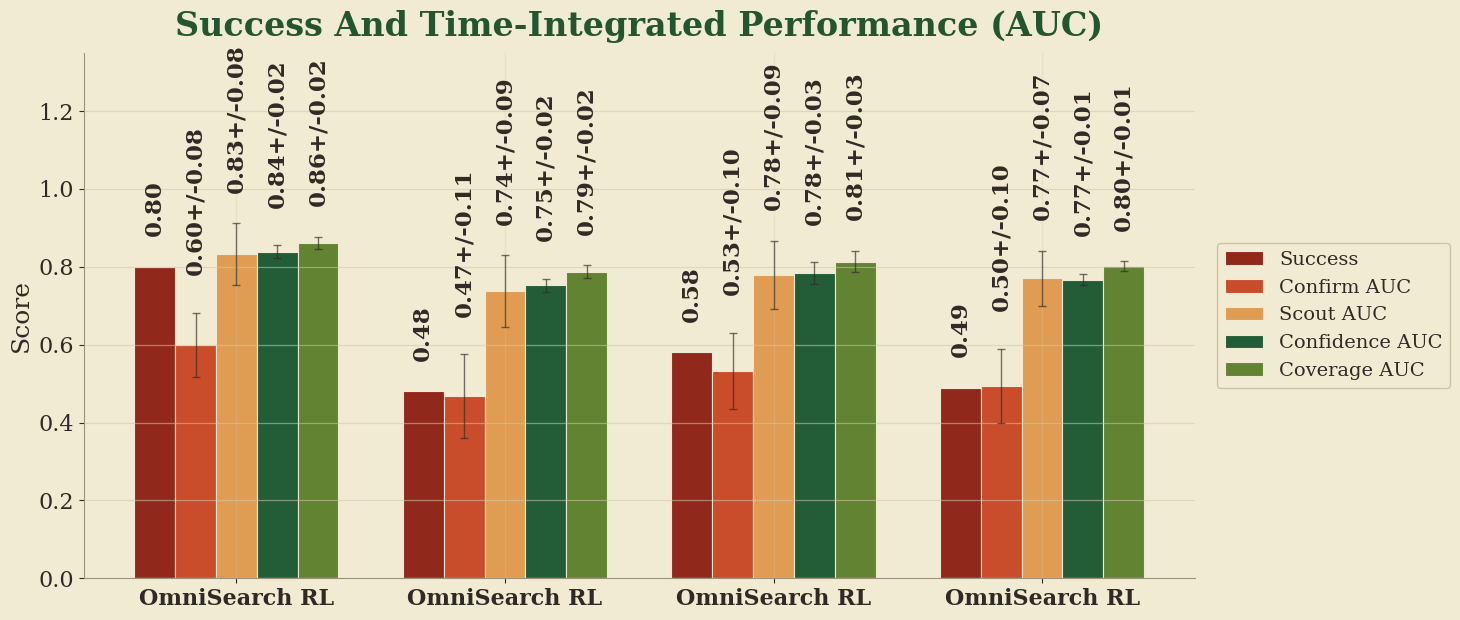

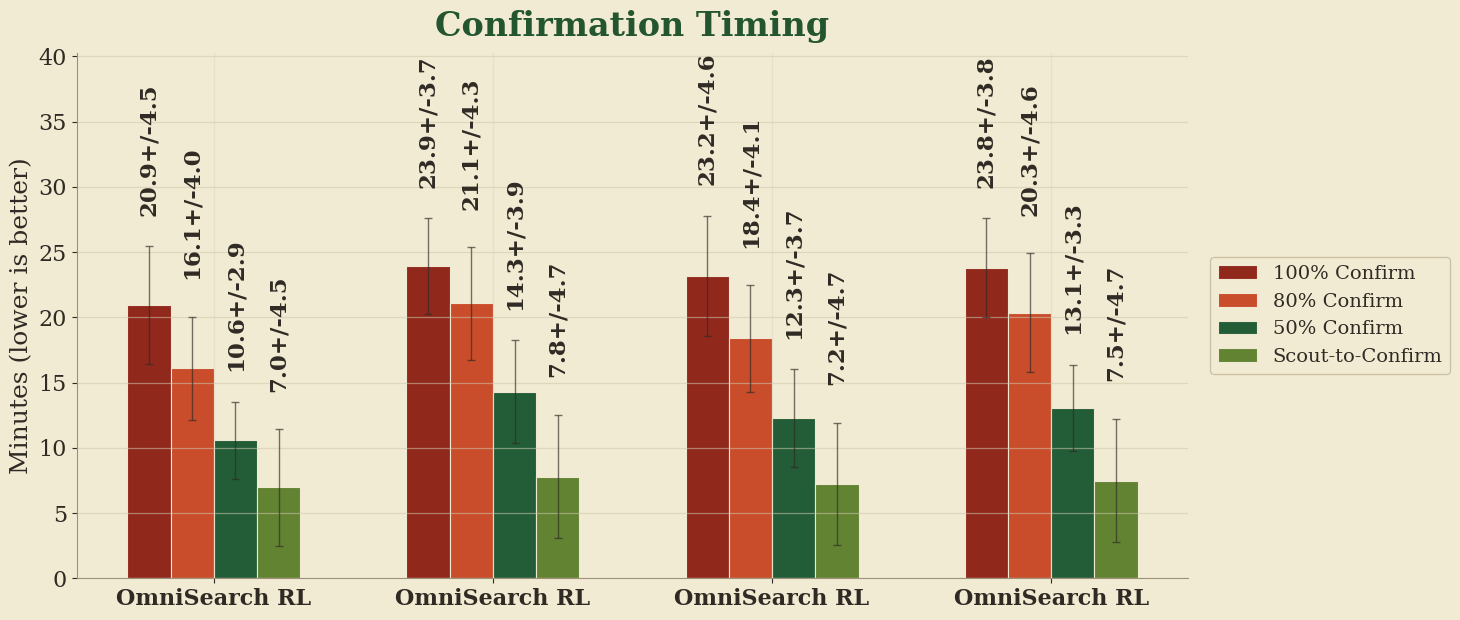

In [15]:
import textwrap

PAPER_BG = '#f2ebd3ff'
GRID_COLOR = '#cfc7ad'
TEXT_GREEN = '#23562f'
TEXT_DARK = '#2f2a24'
AUC_METRIC_SPECS = [
    ('success', 'Success', '#8f2418', 's'),
    ('confirm_auc', 'Confirm AUC', '#c94a27', 's'),
    ('scout_auc', 'Scout AUC', '#e09b4f', 'o'),
    ('confidence_auc', 'Confidence AUC', '#1f5a35', '^'),
    ('coverage_auc', 'Coverage AUC', '#5f812f', 'v'),
]
TIME_METRIC_SPECS = [
    ('confirm_time_100', '100% Confirm', '#8f2418'),
    ('confirm_time_080', '80% Confirm', '#c94a27'),
    ('confirm_time_050', '50% Confirm', '#1f5a35'),
    ('scout_to_confirm_latency', 'Scout-to-Confirm', '#5f812f'),
]

plot_df = metrics.copy().reset_index(drop=True)
for prefix in (
    'confirm_time_100',
    'confirm_time_080',
    'confirm_time_050',
    'scout_to_confirm_latency',
):
    plot_df[f'{prefix}_mean_min'] = pd.to_numeric(plot_df[f'{prefix}_mean_s'], errors='coerce') / 60.0
    plot_df[f'{prefix}_std_min'] = pd.to_numeric(plot_df[f'{prefix}_std_s'], errors='coerce') / 60.0

happo_plot_df = plot_df.loc[
    plot_df['strategy'].astype(str).str.replace('-', '_').eq('happo')
].reset_index(drop=True)

plt.rcParams.update({
    'figure.facecolor': PAPER_BG,
    'axes.facecolor': PAPER_BG,
    'axes.edgecolor': '#f2ebd3ff',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.color': TEXT_DARK,
    'axes.labelcolor': TEXT_DARK,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'legend.frameon': True,
    'font.family': 'serif',
})


def _available_specs(specs, df, *, mean_suffix='_mean'):
    keep = []
    for spec in specs:
        prefix = spec[0]
        col = f'{prefix}{mean_suffix}'
        if col in df.columns and pd.to_numeric(df[col], errors='coerce').notna().any():
            keep.append(spec)
    return keep


def _wrapped_labels(labels, width=16):
    return ['\n'.join(textwrap.wrap(str(label), width=width)) or str(label) for label in labels]


def _add_bar_labels(ax, bars, std, *, offset_rank=0, suffix='', digits=2, show_error=True):
    for bar, err in zip(bars, std):
        height = bar.get_height()
        if not np.isfinite(height):
            continue
        err = 0.0 if not np.isfinite(err) else float(err)
        label_err = err if show_error else 0.0
        label_text = f'{height:.{digits}f}{suffix}'
        if show_error:
            label_text = f'{height:.{digits}f}+/-{err:.{digits}f}{suffix}'
        ax.annotate(
            label_text,
            xy=(bar.get_x() + bar.get_width() / 2.0, height + label_err),
            xytext=(0, 22 + 5 * (offset_rank % 2)),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=16.5,
            fontweight='bold',
            rotation=90,
            linespacing=0.9,
            color=TEXT_DARK,
            clip_on=False,
        )


def _plot_grouped_bars(ax, df, specs, *, title, ylabel, mean_suffix='_mean', std_suffix='_std', y_limit=None, label_suffix='', label_digits=2):
    specs = _available_specs(specs, df, mean_suffix=mean_suffix)
    if not specs:
        ax.set_axis_off()
        ax.set_title(f'{title} not available', color=TEXT_GREEN, pad=12)
        return
    positions = np.arange(len(df))
    width = min(0.155, 0.76 / max(len(specs), 1))
    offset_units = np.arange(len(specs), dtype=float) - (len(specs) - 1) / 2.0
    series = []
    ymax = 1.0
    for prefix, label, color, *_rest in specs:
        mean = pd.to_numeric(df[f'{prefix}{mean_suffix}'], errors='coerce').to_numpy(dtype=float)
        std = pd.to_numeric(df[f'{prefix}{std_suffix}'], errors='coerce').to_numpy(dtype=float)
        plot_mean = np.where(np.isfinite(mean), mean, 0.0)
        show_error = prefix != 'success'
        plot_std = np.where(np.isfinite(std) & show_error, std, 0.0)
        if len(plot_mean):
            ymax = max(ymax, float(np.nanmax(plot_mean + plot_std)) * 1.45)
        series.append((prefix, label, color, mean, std, plot_mean, plot_std, show_error))
    if y_limit is None:
        ax.set_ylim(0.0, ymax)
    else:
        ax.set_ylim(*y_limit)
    for offset, (_prefix, label, color, mean, std, plot_mean, plot_std, show_error) in enumerate(series):
        bar_x = positions + offset_units[offset] * width
        bars = ax.bar(
            bar_x,
            plot_mean,
            width=width,
            yerr=plot_std,
            capsize=3 if show_error else 0,
            color=color,
            alpha=0.98,
            label=label,
            edgecolor=PAPER_BG,
            linewidth=0.8,
            error_kw={'elinewidth': 1.0, 'alpha': 0.65, 'ecolor': TEXT_DARK},
        )
        _add_bar_labels(ax, bars, std, offset_rank=offset, suffix=label_suffix, digits=label_digits, show_error=show_error)
    if 'terrain' in df.columns:
        labels = [
            TERRAIN_LABELS.get(str(name), str(name).replace('_', ' ').title())
            for name in df['terrain']
        ]
    else:
        labels = df['label'].str.replace(r' \| .*$', '', regex=True).tolist()
    ax.set_xticks(positions)
    ax.set_xticklabels(_wrapped_labels(labels), rotation=0, ha='center', fontweight='bold', fontsize=16)
    ax.set_title(title, color=TEXT_GREEN, pad=12)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', color=GRID_COLOR, alpha=0.55, linewidth=0.9)
    ax.grid(axis='x', color=GRID_COLOR, alpha=0.30, linewidth=0.9)
    ax.spines['left'].set_color('#9d9279')
    ax.spines['bottom'].set_color('#9d9279')
    legend = ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        title=None,
        fontsize=14,
    )
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')
    legend.get_frame().set_alpha(0.90)


def _plot_confirm_auc_by_terrain(ax, df):
    terrain_order = list(TERRAIN)
    terrain_positions = np.arange(len(terrain_order), dtype=float)
    colors = ['#8f2418', '#1f5a35', '#e09b4f', '#5f812f', '#c94a27']
    markers = ['o', 's', '^', 'v', 'D']
    configured = [str(strategy).replace('-', '_') for strategy in STRATEGIES]
    observed = [str(strategy).replace('-', '_') for strategy in df['strategy'].dropna().unique()]
    strategy_order = configured + [strategy for strategy in observed if strategy not in configured]
    plotted = []

    for strategy_index, strategy in enumerate(strategy_order):
        group = df.loc[
            df['strategy'].astype(str).str.replace('-', '_').eq(strategy)
        ].copy()
        if group.empty:
            continue
        group = group.drop_duplicates('terrain', keep='last').set_index('terrain').reindex(terrain_order)
        mean = pd.to_numeric(group['confirm_auc_mean'], errors='coerce').to_numpy(dtype=float)
        std = pd.to_numeric(group['confirm_auc_std'], errors='coerce').to_numpy(dtype=float)
        valid = np.isfinite(mean)
        if not valid.any():
            continue
        x = terrain_positions[valid]
        mean = mean[valid]
        std = np.where(np.isfinite(std[valid]), std[valid], 0.0)
        color = colors[strategy_index % len(colors)]
        label = STRATEGY_LABELS.get(strategy, strategy.replace('_', ' ').title())
        ax.fill_between(
            x,
            np.clip(mean - std, 0.0, 1.0),
            np.clip(mean + std, 0.0, 1.0),
            color=color,
            alpha=0.12,
            linewidth=0,
        )
        ax.plot(
            x,
            mean,
            color=color,
            marker=markers[strategy_index % len(markers)],
            markersize=9,
            linewidth=3.0,
            label=label,
        )
        plotted.append(label)

    if not plotted:
        ax.set_axis_off()
        ax.set_title('Confirm AUC Across Terrains not available', color=TEXT_GREEN, pad=12)
        return

    terrain_labels = [
        TERRAIN_LABELS.get(name, str(name).replace('_', ' ').title())
        for name in terrain_order
    ]
    ax.set_xticks(terrain_positions)
    ax.set_xticklabels(_wrapped_labels(terrain_labels), fontweight='bold', fontsize=15)
    ax.set_xlim(-0.2, max(len(terrain_order) - 0.8, 0.8))
    ax.set_ylim(0.0, 1.05)
    ax.set_title('Confirmation AUC Across Terrains', color=TEXT_GREEN, pad=12)
    ax.set_xlabel('Terrain')
    ax.set_ylabel('Confirm AUC')
    ax.grid(axis='y', color=GRID_COLOR, alpha=0.55, linewidth=0.9)
    ax.grid(axis='x', color=GRID_COLOR, alpha=0.30, linewidth=0.9)
    ax.spines['left'].set_color('#9d9279')
    ax.spines['bottom'].set_color('#9d9279')
    legend = ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        fontsize=14,
    )
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')
    legend.get_frame().set_alpha(0.90)


fig, ax = plt.subplots(figsize=(max(18, len(happo_plot_df) * 2.4), 6.3), facecolor=PAPER_BG)
_plot_grouped_bars(
    ax,
    happo_plot_df,
    AUC_METRIC_SPECS,
    title='HAPPO Success And Time-Integrated Performance (AUC)',
    ylabel='Score',
    y_limit=(0.0, 1.35),
    label_digits=2,
)
fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()

fig, ax = plt.subplots(figsize=(max(18, len(happo_plot_df) * 2.4), 6.3), facecolor=PAPER_BG)
_plot_grouped_bars(
    ax,
    happo_plot_df,
    TIME_METRIC_SPECS,
    title='HAPPO Confirmation Timing',
    ylabel='Minutes (lower is better)',
    mean_suffix='_mean_min',
    std_suffix='_std_min',
    label_suffix='',
    label_digits=1,
)
fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()

fig, ax = plt.subplots(figsize=(11.5, 6.3), facecolor=PAPER_BG)
_plot_confirm_auc_by_terrain(ax, plot_df)
fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()
